# Regression Trees

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import re
import numpy as np

In [13]:
df = pd.read_csv('bases/auto-mpg.csv')

In [4]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [5]:
df['horsepower'].unique()

<StringArray>
['130', '165', '150', '140', '198', '220', '215', '225', '190', '170', '160',
  '95',  '97',  '85',  '88',  '46',  '87',  '90', '113', '200', '210', '193',
   '?', '100', '105', '175', '153', '180', '110',  '72',  '86',  '70',  '76',
  '65',  '69',  '60',  '80',  '54', '208', '155', '112',  '92', '145', '137',
 '158', '167',  '94', '107', '230',  '49',  '75',  '91', '122',  '67',  '83',
  '78',  '52',  '61',  '93', '148', '129',  '96',  '71',  '98', '115',  '53',
  '81',  '79', '120', '152', '102', '108',  '68',  '58', '149',  '89',  '63',
  '48',  '66', '139', '103', '125', '133', '138', '135', '142',  '77',  '62',
 '132',  '84',  '64',  '74', '116',  '82']
Length: 94, dtype: str

In [6]:
# Eliminando valores '?'
# re.sub('?', np.nan, df['horsepower'])
# df['horsepower'].fillna(df['horsepower'].median(), inplace=True)
df = df[df['horsepower']!='?']

In [7]:
features = ['horsepower', 'weight']
# Garantindo que estão no formato correto
for ft in features:
    df[ft] = pd.to_numeric(df[ft])
# Construindo matriz de features e vetor de true labels
X = df[features]
y = df['mpg'].values.tolist()

In [8]:
X

,horsepower,weight
0,130,3504
1,165,3693
2,150,3436
3,150,3433
4,140,3449
...,...,...
393,86,2790
394,52,2130
395,84,2295
396,79,2625


In [9]:
# Instanciando
reg = DecisionTreeRegressor(max_depth=2, min_samples_split=3)

In [10]:
# Fit
reg.fit(X,y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes m

In [11]:
# Visualizando
print(tree.export_text(reg))

|--- feature_1 <= 2764.50
|   |--- feature_0 <= 70.50
|   |   |--- value: [33.68]
|   |--- feature_0 >  70.50
|   |   |--- value: [27.01]
|--- feature_1 >  2764.50
|   |--- feature_0 <= 127.00
|   |   |--- value: [20.67]
|   |--- feature_0 >  127.00
|   |   |--- value: [14.72]



In [12]:
#predict
reg.predict([['300','4000']])

c:\Users\gabri\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([14.72142857])

# Prunning

In [14]:
# vamos usar um dataset diferente para entender o processo de prunning
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y=True)

In [15]:
#separando o arquivo em conjunto de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [16]:
#Calculando Cost Complexity Pruning
# Aqui, vou usar Decision Tree Classifier, voltado para classificação, apenas para fins didáticos. O processo é o mesmo para regressão
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
path = clf.cost_complexity_pruning_path(X_train,y_train)

In [17]:
path

{'ccp_alphas': array([0.        , 0.00226647, 0.00464743, 0.0046598 , 0.0056338 ,
        0.00704225, 0.00784194, 0.00911402, 0.01144366, 0.018988  ,
        0.02314163, 0.03422475, 0.32729844]),
 'impurities': array([0.        , 0.00453294, 0.01847522, 0.02313502, 0.02876883,
        0.03581108, 0.04365302, 0.05276704, 0.0642107 , 0.0831987 ,
        0.10634033, 0.14056508, 0.46786352])}

In [18]:
# obtendo valores de alpha e impureza
ccp_alphas, impurities = path.ccp_alphas, path.impurities

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

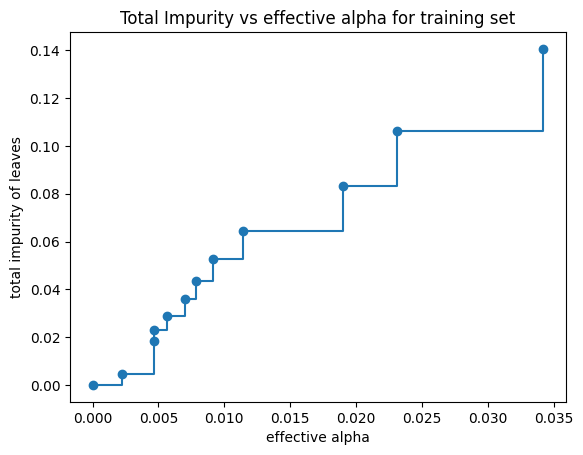

In [19]:
# plot
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

In [20]:
# Treinando a árvore com diferentes valores de alpha
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.3272984419327777


In [21]:
# eliminando o último elemento de clfs e ccp_alphas por que representa a árvore com apenas uma folha
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

In [22]:
clfs

[DecisionTreeClassifier(ccp_alpha=np.float64(0.0), random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.0022664723976040134),
                        random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.004647426339100881),
                        random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.004659799593581376),
                        random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.005633802816901408),
                        random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.007042253521126761),
                        random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.007841938420144537),
                        random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.009114019793328328),
                        random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.011443661971830986),
                        random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.018988002086

In [23]:
#Obtendo os scores para cada valor de aplha
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

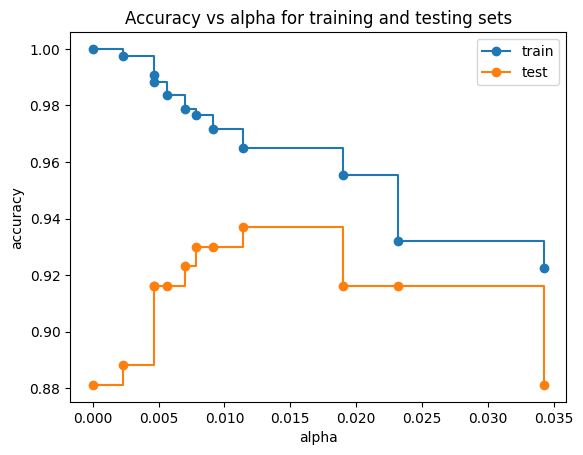

In [24]:
#plotando
fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

# Decision Trees

In [31]:
import os
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "decision_trees"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "github.com/dhenyfernandes/16DTSR/tree/4d9f5d992851abdfe86e6a5af7f1dabf45fb4efa/images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)


In [32]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
 
iris = load_iris()
X = iris.data[:, 2:] # petal length and width
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X, y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

É possível visualizar a árvore de decisão treinada usando o método export_graphviz(). 
OBS: Verifique se o pacote está instalado

In [33]:
from sklearn.tree import export_graphviz

def image_path(fig_id):
    return os.path.join(IMAGES_PATH, fig_id)

export_graphviz(
        tree_clf,
        out_file=image_path("iris_tree.dot"),
        feature_names=iris.feature_names[2:],
        class_names=iris.target_names,
        rounded=True,
        filled=True
    )

Agora, vá em File -> New -> Terminal:

1. Navegue até a pasta onde o arquivo ires_tree.dot foi gerado 
2. Execute o seguinte código: dot -Tpng .\iris_tree.dot -o iris_tree.png

Isso vai gerar um arquivo png que mostrará como ficou nossa árvore. Vou adicioná-la aqui para facilitar nosso entendimento

<img src="images/decision_trees/iris_tree.png" />

### Como o classificador realiza novas predições?

- Começando pela raiz, verifique se o comprimento da pétala é menor que 2.45cm.

    - Se for, vá para o nó da esquerda. Como é um nó folha, a árvore prediz que a classe é setosa
    
    - Se não, vá para o nó da direita. Verifique se a largura da folha é menor que 1.75cm.
    
        - Se for, vá para o nó folha da esquerda. A flor será classificada como versicolor
        
        - Se não, vá para o nó folha da direita. A flor será classificada como virginica

### Desicion Boundaries
É possível verificar as fronteiras de decisão que o arquivo encontrou na construção da árvore. O código abaixo nos fornece uma visualização. 

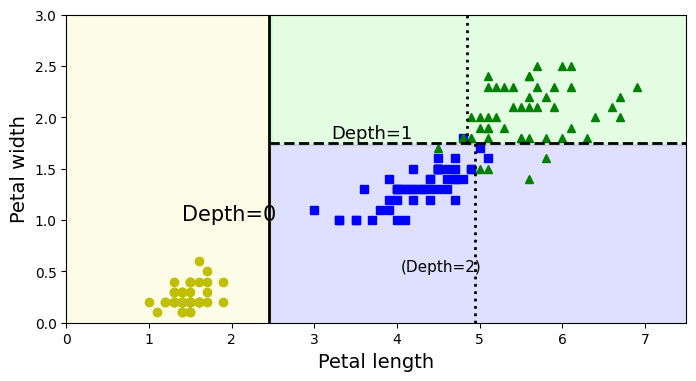

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, axes=[0, 7.5, 0, 3], iris=True, legend=False, plot_training=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if not iris:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    if plot_training:
        plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
        plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
        plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="Iris virginica")
        plt.axis(axes)
    if iris:
        plt.xlabel("Petal length", fontsize=14)
        plt.ylabel("Petal width", fontsize=14)
    else:
        plt.xlabel(r"$x_1$", fontsize=18)
        plt.ylabel(r"$x_2$", fontsize=18, rotation=0)
    if legend:
        plt.legend(loc="lower right", fontsize=14)

plt.figure(figsize=(8, 4))
plot_decision_boundary(tree_clf, X, y)
plt.plot([2.45, 2.45], [0, 3], "k-", linewidth=2)
plt.plot([2.45, 7.5], [1.75, 1.75], "k--", linewidth=2)
plt.plot([4.95, 4.95], [0, 1.75], "k:", linewidth=2)
plt.plot([4.85, 4.85], [1.75, 3], "k:", linewidth=2)
plt.text(1.40, 1.0, "Depth=0", fontsize=15)
plt.text(3.2, 1.80, "Depth=1", fontsize=13)
plt.text(4.05, 0.5, "(Depth=2)", fontsize=11)

plt.show()

A linha mais grossa representa a fronteira de decisão do nó raiz: petal length = 2.45cm. Como a área à esquerda é pura, não há mais splits. Entretanto, a área à direita é impura, então o nó é dividido quando petal width = 1.75cm. Visto que max_depth=2, Decision Tree para aqui. 

### Estimando as probabilidades das classes

Uma Árvore de Decisão pode estimar a probabilidade de uma instância pertencer a uma classe particular. Suponha que uma flor tenha 5cm de comprimento e 1.5cm de largura. O nó correspondente seria o Depth-2 a esquerda. Nesse caso, a Árvore retornaria as seguintes probabilidades:

- 0% parra *Iris Setosa* (0/54)
- 90.7% para *Iris Versicolor* (49/54)
- 9.3% para Iris Virginica* (5/54)

In [35]:
tree_clf.predict_proba([[5, 1.5]])

array([[0.        , 0.90740741, 0.09259259]])

E se você solicitar a predição da classe, o algoritmo retornará *Iris versicolor* (classe 1), visto que ela possui a maior probabilidade:

In [36]:
tree_clf.predict([[5, 1.5]])

array([1])

### Regularização dos Hiperparâmetros

Árvores de decisão assumem poucas suposições acerca dos dados de treinamento (ao contrário dos modelos lineares, que assumem que os dados são lineares). Se deixada sem restrição, a árvore irá se adaptar aos dados de treino, dando um fit muito próximo (na verdade, overfit). 

Tais modelos são chamados não-paramétricos, mas não porque não possuem parâmetros (ou hiperparâmetros), mas porque o número de parâmetros não é determinado antes do treino.

PAra evitar overfitting, é preciso restringir a liberdade da Árvore de Decisão durante o treinamento. Isto é chamado de regularização. Alguns hiperparâmetros que podem ser ajustados para evitar overfitting numa Árvore de decisão:

- max_depth (profundidade máxima da árvore - delimita o número de splits)
- min_samples_split (número mínimo de amostras que um nó deve ter antes do split)
- min_sampes_leaf (número mínimo de amostras que um nó folha deve ter)

O código abaixo apresenta duas Árvores treinadas no dataset moons. A da esquerda foi treinada com hiperparâmetros padrões (sem restrições), enquanto a da direita foi regularizada (min_samples_leaf=4). 

Podemos observar que o modelo da esquerda está dando overfiting e que o modelo da direita irá generalizar melhor. 

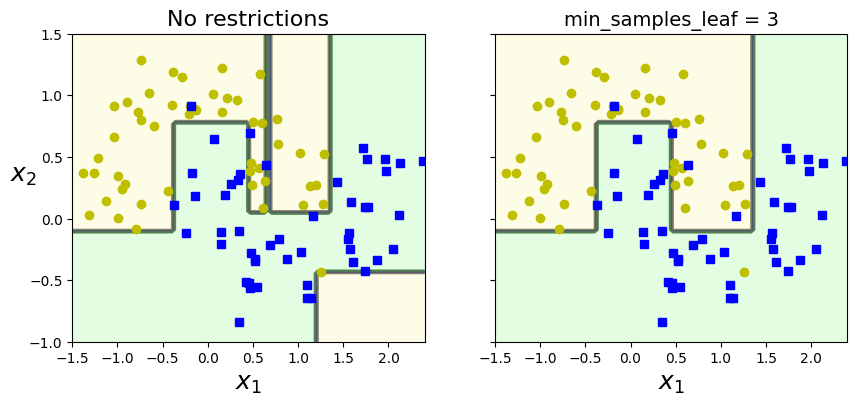

In [37]:
from sklearn.datasets import make_moons
Xm, ym = make_moons(n_samples=100, noise=0.25, random_state=53)

deep_tree_clf1 = DecisionTreeClassifier(random_state=42)
deep_tree_clf2 = DecisionTreeClassifier(max_depth=5, min_samples_leaf=3,random_state=42)
deep_tree_clf1.fit(Xm, ym)
deep_tree_clf2.fit(Xm, ym)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(deep_tree_clf1, Xm, ym, axes=[-1.5, 2.4, -1, 1.5], iris=False)
plt.title("No restrictions", fontsize=16)
plt.sca(axes[1])
plot_decision_boundary(deep_tree_clf2, Xm, ym, axes=[-1.5, 2.4, -1, 1.5], iris=False)
plt.title("min_samples_leaf = {}".format(deep_tree_clf2.min_samples_leaf), fontsize=14)
plt.ylabel("")

plt.show()